<img src=https://www.udc.es/export/sites/udc/silazarillo/_galeria_imgs/03_Simbolo_logo_cor.png_2063069294.png width="300" align="left">
<br />

# Modelos Avanzados de Aprendizaje Automático II
#### <font color=green>*Grado en Inteligencia Artificial*</font>

# Tema 2: Agrupamiento (clustering)

#### Ejercicio sobre el uso de algoritmos de agrupamiento ($k$-medias) sobre el conjunto de datos de los dígitos manuscritos

#### Se cargan las librerías necesarias:

In [91]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import mode
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.cluster import KMeans, DBSCAN
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import silhouette_score, ConfusionMatrixDisplay
from sklearn.metrics.cluster import v_measure_score, rand_score
from sklearn.datasets import load_digits
from sklearn.manifold import TSNE
import seaborn as sns

#### Cargamos los datos (load_digits()). En la matriz de datos, cada fila se corresponde con la imagen de un dígito. Los píxeles de la imagen rectangular de 8×8 píxeles se han recolocado en una fila de 64 elementos. Por lo tanto, cada fila es un objeto o dato. Las características o propiedades de cada objeto son las intensidades de gris de cada pixel. Es decir, tenemos, para cada imagen, 64 propiedades.

In [64]:
dct = load_digits()
data = dct["data"]
targets = dct["target"]

#### Para visualizar mejor los dígitos, se invierten los colores.
#### Fijamos la semilla para inicializar los centroides, para que los resultados sean repetibles.
#### Fijamos $k$ teniendo en cuenta el número de dígitos diferentes.

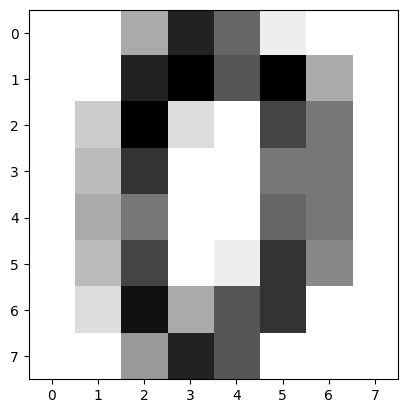

In [ ]:
inv_data = -1 * (data - 16)
seed = np.random.RandomState(250)
k = 10
plt.imshow(inv_data[0].reshape(8, 8), cmap="gray")


#### Se realiza el agrupamiento (clustering) mediante el uso del método [$k$-medias](https://scikit-learn.org/stable/modules/generated/sklearn.cluster.KMeans.html). 

In [66]:
kmeans = KMeans(n_clusters=k, random_state=seed, n_init="auto").fit(inv_data)

#### Se muestra gráficamente los centroides de los agrupamientos.

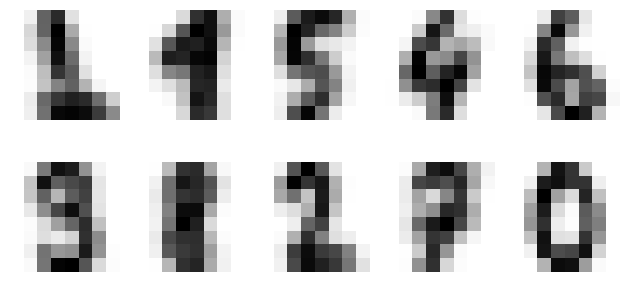

In [53]:
fig, axes = plt.subplots(2, 5)
for ax, centr in zip(axes.flatten(), kmeans.cluster_centers_):
    ax.imshow(centr.reshape(8, 8), cmap = "gray")
    ax.axis("off")
    fig.tight_layout()
plt.show()


#### Se muestra gráficamente el resultado del agrupamiento: para cada una de las 10 clases, mostramos las imágenes que han sido asignadas a esa clase. 

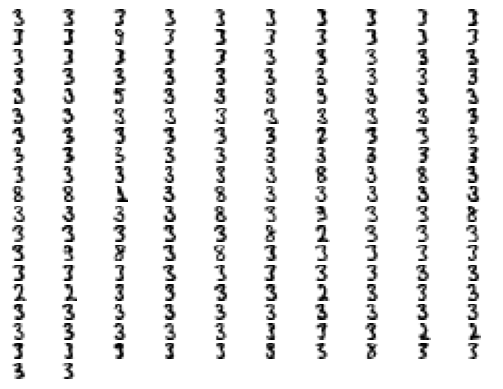

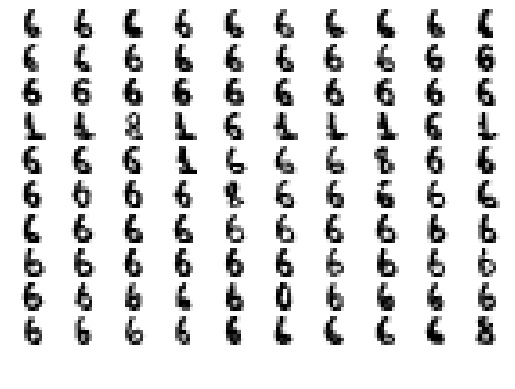

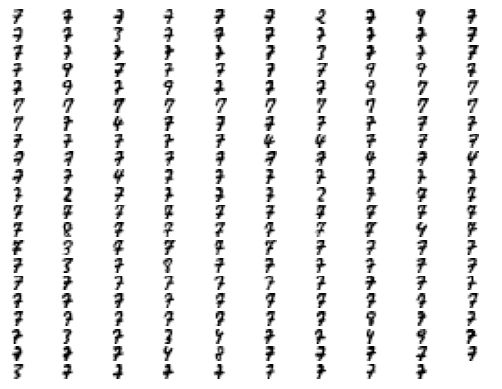

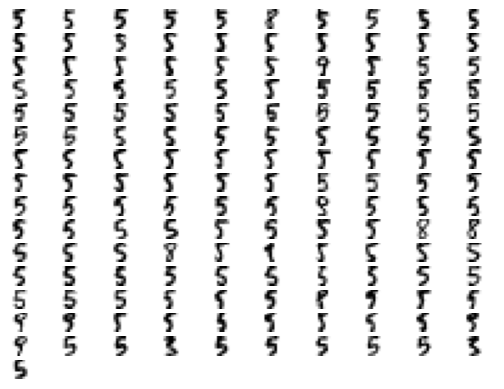

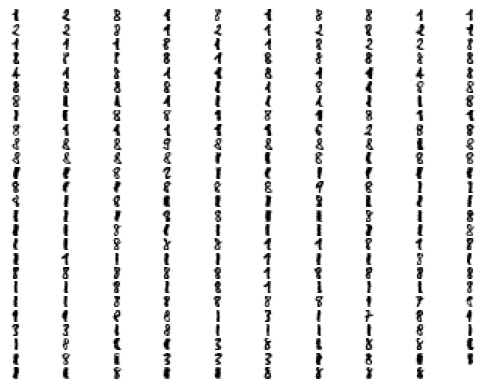

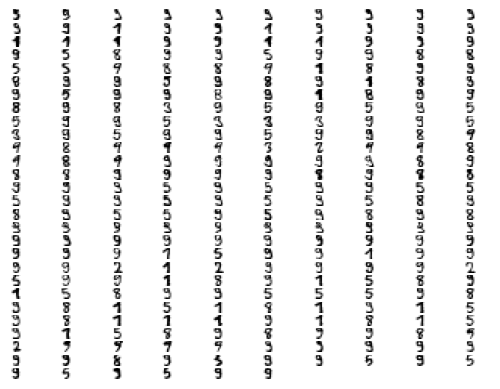

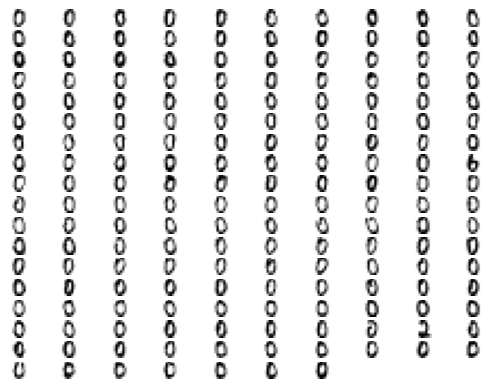

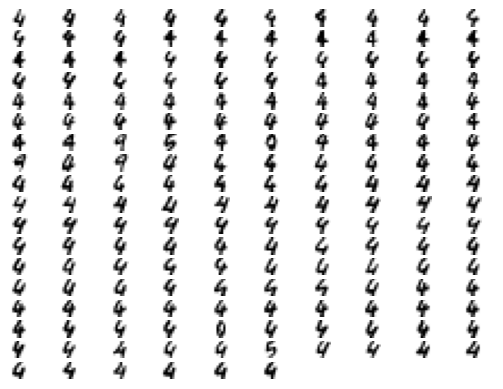

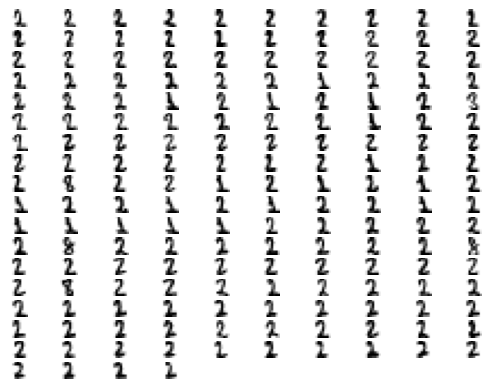

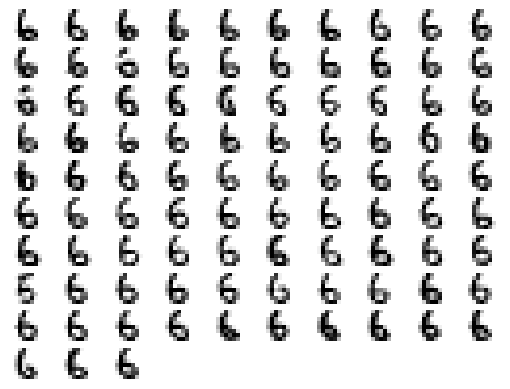

In [138]:
for i in range(k):
    mask = kmeans.labels_ == i
    cnt = np.count_nonzero(mask)
    rows = (cnt // 10) + 1
    fig, axes = plt.subplots(rows, 10)
    for n, ax in enumerate(axes.flatten()):
        if n < cnt: ax.imshow(inv_data[mask][n].reshape(8, 8), cmap="gray")
        ax.axis("off")
    plt.show()


#### Muestra una tabla con los resultados de las medidas de rendimiento (silhouette, v_measure, rand_indx) para al menos dos inicializaciones de los centroides. 

In [ ]:
exec_num = 5
execs = [KMeans(n_clusters=k, random_state=seed, n_init="auto").fit(inv_data) for _ in range(exec_num)]
print("\t" + silhouette_score.__name__ + "\t" + v_measure_score.__name__ + "\t\t" + rand_score.__name__)
for i, exec in enumerate(execs):
    print(f"Exec{i + 1}", end = " ")
    print(silhouette_score(data, exec.labels_), end="\t")
    print(v_measure_score(targets, exec.labels_),  end="\t")
    print(rand_score(targets, exec.labels_),  end=" ")
    print("\n")

	silhouette_score	v_measure_score		rand_score
Exec1 0.17419929072402007	0.7532248049996433	0.9369971977547336 

Exec2 0.17344392375862697	0.7093243470963869	0.9138994339737226 

Exec3 0.1874483466721669	0.7494771921908694	0.9334940813258426 

Exec4 0.18838936538883155	0.7539055138978826	0.9345996110815725 

Exec5 0.15903399233432955	0.7103067375066685	0.9139750363449104 



#### Como k-means no sabe nada sobre la identidad del agrupamiento, las etiquetas 0-9 pueden estar permutadas. 
#### Hacer que cada etiqueta de clúster aprendida coincida con las etiquetas verdaderas que se encuentran en ellos.

In [79]:
clusters = kmeans.labels_
labels = np.zeros_like(clusters)
for i in range(10):
    mask = (clusters == i)
    labels[mask] = mode(targets[mask], keepdims='True')[0]

#### Comprobar la precisión de la agrupación no supervisada a la hora de encontrar dígitos similares en los datos.

In [80]:
accuracy_score(targets, labels)

0.7963272120200334

#### Comprobamos la matriz de confusión para determinar en que dígitos se cometen más errores.

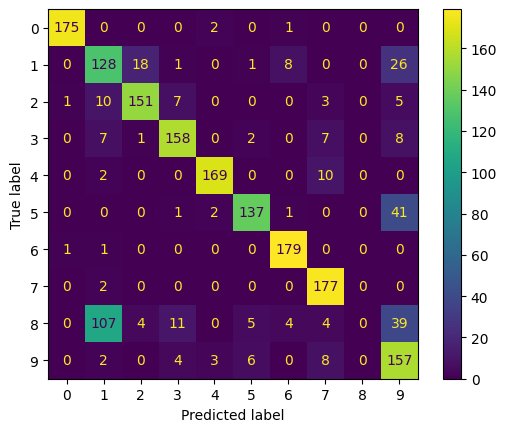

In [92]:
ConfusionMatrixDisplay(confusion_matrix(targets, labels)).plot()

#### Podemos utilizar el algoritmo t-SNE (t-distributed stochastic neighbor embedding) para preprocesar los datos antes de realizar k-means. t-SNE es un algoritmo de incrustación no lineal que es particularmente experto en preservar puntos dentro de clusters. Comprueba como cambian tanto la precisión como las medidas de rendimiento calculadas anteriormente. Utilizar la utilización aleatoria de los centroides.

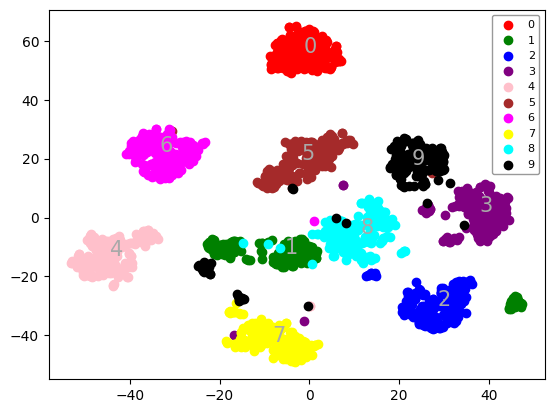

	silhouette_score	v_measure_score		rand_score
Exec1 0.16338708510339103	0.9082720131815809	0.9788914461494225 

Exec2 0.16342408483067275	0.9118849641926077	0.9801023234715618 

Exec3 0.16338708510339103	0.9082720131815807	0.9788914461494225 

Exec4 0.16338708510339103	0.9082720131815807	0.9788914461494225 

Exec5 0.16342408483067275	0.9118849641926077	0.9801023234715618 

Acuracy:  0.9410127991096272


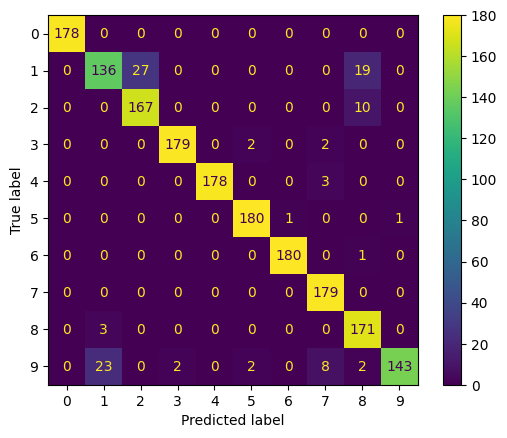

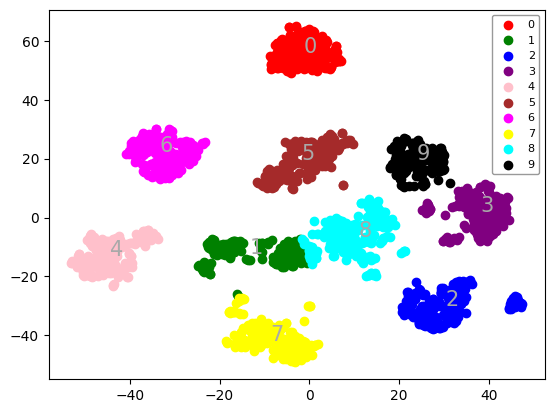

In [137]:
def draw(pts, labels):
    ulab = np.unique(labels)
    colors = dict(zip(ulab, ["red", "green", "blue", "purple", "pink", "brown", "magenta", "yellow", "cyan", "black"]))
    fig = plt.figure()
    if np.shape(pts)[1] == 3:
        ax = fig.add_subplot(projection="3d")
        for key in colors:
            mask = [i == key for i in labels]
            ax.scatter(pts[:, 0][mask], pts[:, 1][mask], pts[:, 2][mask], c=colors[key], label = key)
    else:
        ax = fig.add_subplot()
        for key in colors:
            mask = [i == key for i in labels]
            ax.scatter(pts[:, 0][mask], pts[:, 1][mask], c=colors[key], label = key,)
            midpoint = np.median(pts[mask], axis=0)
            plt.text(midpoint[0], midpoint[1], key, fontsize=15, color="darkgray")
    plt.legend(fontsize=8, frameon=True, framealpha=0.8, edgecolor='gray')
    plt.show()

tsne = TSNE(n_components=2)
dcomp_data = tsne.fit_transform(inv_data)
draw(dcomp_data, targets)

tsnekmeans = KMeans(n_clusters=k, random_state=seed, n_init="auto").fit(dcomp_data)
execs = [KMeans(n_clusters=k, random_state=seed, n_init="auto").fit(dcomp_data) for _ in range(exec_num)]
print("\t" + silhouette_score.__name__ + "\t" + v_measure_score.__name__ + "\t\t" + rand_score.__name__)
for i, exec in enumerate(execs):
    print(f"Exec{i + 1}", end = " ")
    print(silhouette_score(data, exec.labels_), end="\t")
    print(v_measure_score(targets, exec.labels_),  end="\t")
    print(rand_score(targets, exec.labels_),  end=" ")
    print("\n")

clusters = tsnekmeans.labels_
labels = np.zeros_like(clusters)
for i in range(10):
    mask = (clusters == i)
    labels[mask] = mode(targets[mask], keepdims='True')[0]
print("Acuracy: ", accuracy_score(targets, labels))
ConfusionMatrixDisplay(confusion_matrix(targets, labels)).plot()
draw(dcomp_data, labels)

## Razona los resultados obtenidos

In [ ]:
# Análisis del método de inicialización de centroides
# Análisis del método de elección del número de grupos (k)
# Comparación con el algoritmo t-SNE